In [8]:
import numpy as np
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import sys, numpy as np

from keras.datasets import mnist
from spacy.lang.ja.syntax_iterators import labels
from srsly.msgpack import epoch
from torch import layout

np.random.seed(1)

# Подготовка данных для тренировки и тестирования
(x_train, y_train), (x_test, y_test) = mnist.load_data()


def prepare_images(images, size=1000):
    return images[0:size].reshape(size, 28 * 28) / 255


def prepare_labels(labels, size=1000):
    labels = labels[0:size]
    on_hot_labels = np.zeros((len(labels), 10))

    for i, l in enumerate(labels):
        on_hot_labels[i][l] = 1

    return on_hot_labels


images, labels = prepare_images(x_train), prepare_labels(y_train)
test_images, test_labels = prepare_images(x_test), prepare_labels(y_test)

4


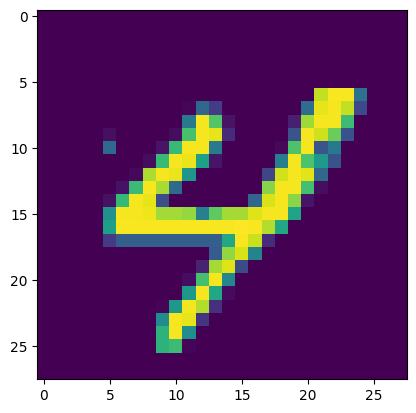

In [22]:
# Visualizing one example:
index = 89
print(y_train[index])
plt.imshow(x_train[index].squeeze())

In [28]:
def get_image_section(layer, row_from, row_to, col_from, col_to):
    sub_section = layer[:, row_from:row_to, col_from:col_to]
    return sub_section.reshape(-1, 1, row_to - row_from, col_to - col_from)

In [ ]:
# activation functions
def tanh(x):
    return np.tanh(x)


def grad_tanh(y):
    return 1 - y ** 2


def softmax(x):
    exps = np.exp(x)
    return exps / np.sum(exps, axis=1, keepdims=True)


lr, epochs = (2, 300)
pixels_per_image, num_labels = (784, 10)
batch_size = 128

input_rows, input_cols = (28, 28)
kernel_rows, kernel_cols = (3, 3)
num_kernels = 4

# `Hidden` is of that size because we are training a 1-D Convolutional Layer, not a 2D, and so it's taking more spaces
hidden_size = ((input_rows - kernel_rows + 1) * (input_cols - kernel_cols + 1)) * num_kernels

kernels = (0.02 * np.random.random((kernel_rows * kernel_cols, num_kernels))) - 0.01
weights_1_2 = (0.2 * np.random.random((hidden_size, num_labels))) - 0.1

kernels.shape, weights_1_2.shape

# Training Loop
for epoch in range(epochs):  # for each epoch
    correct_count = 0
    for batch in range(int(len(images) / batch_size)):  # for each batch
        batch_start, batch_end = (batch * batch_size), ((batch + 1) * batch_size)

        # get input
        layer_0 = images[batch_start:batch_end]
        layer_0 = layer_0.reshape(layer_0.shape[0], 28, 28)

        # extract all sections from all batch images
        sections = list()
        for row_start in range(layer_0.shape[1] - kernel_rows + 1):  # +1 by akramz.
            for col_start in range(layer_0.shape[2] - kernel_cols + 1):
                section = get_image_section(layer_0,
                                            row_start,
                                            row_start + kernel_rows,
                                            col_start,
                                            col_start + kernel_cols)
                sections.append(section)

        # [0] 128 batch elements, [1] 676 sections/image, 3x3 section size
        expanded_input = np.concatenate(sections, axis=1)

        es = expanded_input.shape
        # shape: (128x676, 3x3)
        flattened_input = expanded_input.reshape(es[0] * es[1], -1)

        # forward propagation
        kernel_output = flattened_input.dot(kernels)  # 16 kernels
        layer_1 = tanh(kernel_output.reshape(es[0], -1))
        dropout_mask = np.random.randint(2, size=layer_1.shape)
        layer_1 *= dropout_mask * 2
        layer_2 = softmax(np.dot(layer_1, weights_1_2))

        # count corrects
        for k in range(batch_size):
            labelset = labels[batch_start + k:batch_start + k + 1]
            _inc = int(np.argmax(layer_2[k:k + 1]) == np.argmax(labelset))
            correct_count += _inc

        # back propagation
        layer_2_delta = (labels[batch_start:batch_end] - layer_2) / (batch_size * layer_2.shape[0])
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * grad_tanh(layer_1)
        layer_1_delta *= dropout_mask

        weights_1_2 += lr * layer_1.T.dot(layer_2_delta)
        l1d_reshape = layer_1_delta.reshape(kernel_output.shape)
        k_udpate = flattened_input.T.dot(l1d_reshape)
        kernels -= lr * k_udpate

        # test
        test_correct_count = 0
        for i in range(len(test_images)):
            layer_0 = test_images[i:i + 1]
            layer_0 = layer_0.reshape(layer_0.shape[0], 28, 28)
            sections = list()

            for row_start in range(layer_0.shape[1] - kernel_rows + 1):
                for col_start in range(layer_0.shape[2] - kernel_cols + 1):
                    section = get_image_section(layer_0,
                                                row_start,
                                                row_start + kernel_rows,
                                                col_start,
                                                col_start + kernel_cols)
                    sections.append(section)

            expanded_input = np.concatenate(sections, axis=1)
            es = expanded_input.shape
            flattened_input = expanded_input.reshape(es[0] * es[1], -1)
            kernel_output = flattened_input.dot(kernels)
            layer_1 = tanh(kernel_output.reshape(es[0], -1))
            layer_2 = np.dot(layer_1, weights_1_2)
            test_correct_count += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

    if (epoch % 1 == 0):
        print(
            f"I: {epoch} | Test-Acc: {round(test_correct_count / float(len(test_images)), 5)} | Train-Acc: {round(correct_count / float(len(images)), 5)}")

I: 0 | Test-Acc: 0.077 | Train-Acc: 0.062
I: 1 | Test-Acc: 0.072 | Train-Acc: 0.064
I: 2 | Test-Acc: 0.069 | Train-Acc: 0.064
I: 3 | Test-Acc: 0.079 | Train-Acc: 0.061
I: 4 | Test-Acc: 0.094 | Train-Acc: 0.069
I: 5 | Test-Acc: 0.102 | Train-Acc: 0.07
I: 6 | Test-Acc: 0.124 | Train-Acc: 0.09
I: 7 | Test-Acc: 0.138 | Train-Acc: 0.091
I: 8 | Test-Acc: 0.155 | Train-Acc: 0.121
I: 9 | Test-Acc: 0.169 | Train-Acc: 0.109
I: 10 | Test-Acc: 0.193 | Train-Acc: 0.151
I: 11 | Test-Acc: 0.21 | Train-Acc: 0.144
I: 12 | Test-Acc: 0.217 | Train-Acc: 0.167
I: 13 | Test-Acc: 0.218 | Train-Acc: 0.159
I: 14 | Test-Acc: 0.198 | Train-Acc: 0.172
I: 15 | Test-Acc: 0.111 | Train-Acc: 0.13
I: 16 | Test-Acc: 0.025 | Train-Acc: 0.062
I: 17 | Test-Acc: 0.013 | Train-Acc: 0.044
I: 18 | Test-Acc: 0.014 | Train-Acc: 0.033
I: 19 | Test-Acc: 0.015 | Train-Acc: 0.042
I: 20 | Test-Acc: 0.026 | Train-Acc: 0.043
I: 21 | Test-Acc: 0.056 | Train-Acc: 0.056
I: 22 | Test-Acc: 0.098 | Train-Acc: 0.094
I: 23 | Test-Acc: 0.168 |